# Author characteristics and collaborative structure

This notebook consolidates the former `05_*` author, gender, geography, institution, and network analyses into one reproducible workflow. Its only source dataset is the Showcase+ all-endpoints-wide parquet. All transformations, statistics, validation rules, plots, captions, and exports live in `utils.data_analysis_05_author_characteristics` and `utils.data_analysis_05_author_plots`; the notebook records the analytical decisions and orchestrates those utilities.

The deliverables are one six-panel headline figure, five single-domain supplementary figures, an author-level table containing UK Biobank-specific impact and network measures, domain tables, a supplementary workbook, figure captions, methods text, validation checks, and an artifact manifest. All displayed and saved paths are repository-relative.

In [1]:
from __future__ import annotations

import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Markdown, display

ROOT = next(path for path in [Path.cwd(), *Path.cwd().parents] if (path / "src" / "utils").is_dir())
sys.path.insert(0, str(ROOT / "src"))

from utils import data_analysis_05_author_characteristics as A
from utils import data_analysis_05_author_plots as F
from utils import shared_paths as P
from utils.shared_style import load_style

P.bootstrap()
P.ensure_dirs()
STYLE = load_style("05_author_characteristics")
ARTIFACTS = P.ArtifactRegistry(P.TABLE_AUTHOR_CHARACTERISTICS)
pd.set_option("display.max_columns", 30)
pd.set_option("display.max_colwidth", 90)
print("Input:", P.raw_path(P.SHOWCASE_PLUS))
print("Figures:", P.raw_path(P.FIG_AUTHOR_CHARACTERISTICS))
print("Tables:", P.raw_path(P.TABLE_AUTHOR_CHARACTERISTICS))

Input: data/showcase/showcase_plus/showcase_plus_all_endpoints_wide.parquet
Figures: output/figures/data_analysis/05_author_characteristics
Tables: output/tables/data_analysis/05_author_characteristics


## Analytical design

The analysis distinguishes publications, author-paper pairs, affiliations, and longitudinally resolved authors. Dimensions `researcher_id` values are the only cross-paper identity key. Missing IDs receive paper-local keys for descriptive denominators and are never merged by name. This avoids falsely combining namesakes, although it means unresolved authorships cannot contribute to person-level h-indices or network trajectories.

Each paper contributes one fractional publication unit, split first among parsed authors and then among each author's distinct institutions or countries. FOR 2020 categories remain multi-label. Name-based Female/Male/Unknown categories are reported as an imperfect proxy rather than self-identified gender, and classification coverage is shown explicitly. Network results use both observed ties and team-size-normalized weights, with a parallel sensitivity excluding papers with more than 100 resolved authors.

In [2]:
source, papers = A.load_author_papers()
parameters = A.analysis_parameters(source, papers)
display(parameters)
display(A.metric_definitions())

,parameter,value
0,input,data/showcase/showcase_plus/showcase_plus_all_endpoints_wide.parquet
1,source_records,26109
2,primary_records,23442
3,first_year,2013
4,last_complete_year,2025
5,provisional_years_excluded,2026
6,author_identity,Dimensions researcher_id
7,unresolved_identity,paper-local key; no cross-paper linkage
8,name_gender_dictionary,gender_guesser; offline
9,hyperauthor_threshold,100


,metric,definition
0,Resolved author,An authorship carrying a Dimensions researcher_id; only these IDs are linked longitudi...
1,Unresolved authorship,An author-paper slot without a researcher_id. It receives a paper-local key and is nev...
2,UKB h-index,Largest h for which an author or institution has h UK Biobank papers cited at least h ...
3,UKB g-index,Largest g for which the g most-cited UK Biobank papers received at least g squared cit...
4,Fractional publication credit,"Each paper contributes one unit split equally among parsed authors, then equally among..."
5,Author-credit concentration,Cumulative share of resolved-author fractional publication credit held by authors rank...
6,Author productivity band,Mutually exclusive grouping of resolved authors by their number of UK Biobank publicat...
7,Modal author assignment,"An author's most frequent FOR, institution or country after each paper is split equall..."
8,Author home assignment,Current organization metadata when its GRID record resolves; otherwise the author's mo...
9,Female-name share,Female-category author-paper pairs divided by female- plus male-category pairs; unknow...


## Canonical author, affiliation, geography, institution, and gender tables

The next call performs all non-network transformations once. In particular, it preserves all reported affiliations rather than selecting an arbitrary first affiliation, resolves organization metadata from GRID IDs, computes paper-conserving fractional credits, and constructs UKB-specific author and institution bibliometrics.

In [3]:
core = A.build_core_tables(papers)
audit_pre_network = A.quality_audit(source, papers, core)
checks_pre_network = A.validation_checks(source, papers, core)
display(audit_pre_network)
display(checks_pre_network)
if not checks_pre_network["passed"].all():
    raise AssertionError("A pre-network validation check failed.")

,metric,value,interpretation
0,Source parquet records,26109.00,includes provisional years
1,Records after 2025,2667.00,excluded from primary analysis
2,Complete-year papers,23442.00,2013-2025
3,Papers with parsed authors,23407.00,author-based denominator
4,Papers without parsed authors,35.00,retained in source audit only
5,Parsed author-paper pairs,274603.00,deduplicated within paper
6,Resolved author-paper pairs,242663.00,Dimensions researcher ID present
7,Unresolved author-paper pairs,31940.00,paper-local IDs; never merged by name
8,Unique resolved authors,69237.00,author table rows
9,Author homes from current organization,62116.00,GRID-resolved current organization


,check,passed,observed,expected
0,unique_source_publication_ids,True,26109,26109
1,complete_year_window,True,2013-2025,2013-2025
2,unique_author_paper_pairs,True,274603,274603
3,authorship_credit_sums_to_one,True,0.0,<=1e-9
4,country_credit_never_exceeds_one,True,1.0,<=1
5,institution_credit_never_exceeds_one,True,1.0,<=1
6,institution_credit_conserved,True,0.0,<=1e-9
7,country_credit_conserved,True,0.0,<=1e-9
8,fractional_credits_nonnegative,True,nonnegative,nonnegative
9,ukb_h_index_bounded_by_papers,True,77,<= n_ukb_papers


## Author-level table and UK Biobank-specific impact

`core.author_metrics` contains one row per Dimensions-resolved author. The `ukb_h_index`, `ukb_g_index`, and `ukb_i10_index` columns use only papers in this UK Biobank corpus and therefore must not be interpreted as whole-career metrics. Network degree, component, and community columns are merged into this table after the network stage.

In [4]:
author_preview_columns = [
    "researcher_id", "full_name", "n_ukb_papers", "fractional_paper_credit",
    "total_ukb_citations", "ukb_h_index", "ukb_g_index", "ukb_i10_index",
    "modal_institution", "modal_country", "modal_for_l2", "name_gender",
]
display(core.author_metrics[author_preview_columns].head(25))

,researcher_id,full_name,n_ukb_papers,fractional_paper_credit,total_ukb_citations,ukb_h_index,ukb_g_index,ukb_i10_index,modal_institution,modal_country,modal_for_l2,name_gender
0,ur.010663343457.34,George Davey Smith,329,39.305765,28121.0,77,165,187,MRC Integrative Epidemiology Unit,United Kingdom,Health Sciences,Male
1,ur.011026120037.74,Ian J. Deary,222,18.132695,30374.0,72,174,152,University of Edinburgh,United Kingdom,Psychology,Male
2,ur.01026114310.09,Naveed Sattar,192,17.057790,26518.0,72,162,145,University of Glasgow,United Kingdom,Biomedical and Clinical Sciences,Male
3,ur.013723776517.34,Nicholas J. Wareham,163,8.003276,34720.0,72,163,129,MRC Epidemiology Unit,United Kingdom,Biomedical and Clinical Sciences,Male
4,ur.01354253237.14,Jill P. Pell,254,28.369818,28895.0,71,169,168,University of Glasgow,United Kingdom,Biomedical and Clinical Sciences,Female
5,ur.0723426172.10,Kari Stefansson,167,3.936184,34234.0,68,167,137,University of Iceland,Iceland,Biological Sciences,Female
6,ur.01223207223.05,Stephen Burgess,216,27.710578,15868.0,62,124,143,University of Cambridge,United Kingdom,Biomedical and Clinical Sciences,Male
7,ur.01317433110.75,Caroline Hayward,165,5.614598,28503.0,62,165,125,MRC Human Genetics Unit,United Kingdom,Biological Sciences,Female
8,ur.010700366647.17,Nicholas G. Martin,141,4.489793,28521.0,62,141,110,QIMR Berghofer Medical Research Institute,Australia,Biological Sciences,Male
9,ur.0616003437.07,Claudia Langenberg,132,5.654241,26259.0,61,132,100,MRC Epidemiology Unit,United Kingdom,Biological Sciences,Female


## Name-inferred gender, geography, and institutions

The annual name-category table includes Female, Male, and Unknown/androgynous counts; Wilson intervals apply only to integer author-paper pairs. Country and institution intersection tables use fractional credit and deliberately omit binomial intervals because fractional allocations are not independent Bernoulli trials.

In [5]:
display(core.gender_by_year.round(2))
display(core.gender_by_role.round(2))
display(core.country_metrics.head(15).round(2))
display(core.institution_metrics.head(15).round(2))

name_gender,year,Female,Male,Unknown,classified,total,female_name_share,unknown_name_share,female_name_ci_low,female_name_ci_high
0,2013,13.0,31.0,1.0,44.0,45.0,29.55,2.22,18.16,44.22
1,2014,77.0,143.0,33.0,220.0,253.0,35.00,13.04,29.00,41.51
2,2015,291.0,475.0,176.0,766.0,942.0,37.99,18.68,34.62,41.48
3,2016,942.0,1636.0,649.0,2578.0,3227.0,36.54,20.11,34.70,38.42
4,2017,1684.0,3132.0,1268.0,4816.0,6084.0,34.97,20.84,33.63,36.33
5,2018,3588.0,6574.0,2644.0,10162.0,12806.0,35.31,20.65,34.38,36.24
6,2019,5348.0,9162.0,3608.0,14510.0,18118.0,36.86,19.91,36.08,37.65
7,2020,5401.0,9512.0,5946.0,14913.0,20859.0,36.22,28.51,35.45,36.99
8,2021,7370.0,12403.0,7625.0,19773.0,27398.0,37.27,27.83,36.60,37.95
9,2022,8194.0,13081.0,12132.0,21275.0,33407.0,38.51,36.32,37.86,39.17


name_gender,authorship_role,Female,Male,Unknown,classified,total,female_name_share,unknown_name_share,female_name_ci_low,female_name_ci_high
0,First author,4931.0,6284.0,11898.0,11215.0,23113.0,43.97,51.48,43.05,44.89
1,Last author,3914.0,8679.0,10520.0,12593.0,23113.0,31.08,45.52,30.28,31.89
2,Middle author,54850.0,88081.0,85152.0,142931.0,228083.0,38.38,37.33,38.12,38.63
3,Single author,49.0,150.0,95.0,199.0,294.0,24.62,32.31,19.16,31.05
4,Corresponding author,4443.0,8422.0,13712.0,12865.0,26577.0,34.54,51.59,33.72,35.36


,iso3,fractional_paper_credit,unique_ukb_papers,first_ukb_year,last_ukb_year,country,iso2,unique_resolved_authors,author_affiliation_rows,classified_name_credit,female_name_credit,female_name_share,author_basis_unique_papers,authors_per_paper,org_basis_unique_papers,author_vs_org_paper_percent
0,CHN,6529.25,7715,2015,2025,China,CN,19213,56486,405.37,118.01,29.11,7715,7.32,7626,101.17
1,USA,5431.81,9050,2013,2025,United States,US,17150,68774,3634.96,1245.90,34.28,9050,7.60,8798,102.86
2,GBR,5181.82,8418,2013,2025,United Kingdom,GB,12971,61117,4055.14,1535.61,37.87,8418,7.26,8122,103.64
3,AUS,810.68,2168,2014,2025,Australia,AU,2184,9530,545.84,214.66,39.33,2168,4.40,2105,102.99
4,DEU,588.01,1890,2015,2025,Germany,DE,2804,9665,488.82,151.88,31.07,1890,5.11,1773,106.60
5,CAN,577.41,1473,2014,2025,Canada,CA,1882,6060,409.90,144.54,35.26,1473,4.11,1412,104.32
6,NLD,524.83,1802,2013,2025,Netherlands,NL,2107,8599,402.51,152.00,37.76,1802,4.77,1740,103.56
7,SWE,416.72,1653,2014,2025,Sweden,SE,1414,5369,308.95,137.95,44.65,1653,3.25,1619,102.10
8,KOR,373.71,590,2016,2025,South Korea,KR,999,3557,92.38,46.68,50.53,590,6.03,573,102.97
9,DNK,260.30,960,2015,2025,Denmark,DK,1085,4197,222.55,66.32,29.80,960,4.37,932,103.00


,institution_id,fractional_paper_credit,unique_ukb_papers,first_ukb_year,last_ukb_year,total_ukb_citations,mean_ukb_citations,median_ukb_citations,max_ukb_citations,total_altmetric,ukb_h_index,ukb_g_index,ukb_i10_index,institution,org_id,country,country_iso3,org_type,unique_resolved_authors,author_affiliation_rows,classified_name_credit,female_name_credit,female_name_share,modal_for_l2,unique_institutional_collaborators,mean_institutions_per_paper,sole_institution_papers
0,grid.4991.5,624.82,1875,2014,2025,161608.0,86.19,11.0,12988.0,221043.0,169,377,969,University of Oxford,grid.4991.5,United Kingdom,GBR,Education,1288,6754,458.62,199.46,43.49,Biomedical and Clinical Sciences,3122,13.24,194
1,grid.8756.c,334.86,685,2013,2025,73703.0,107.60,16.0,12988.0,95738.0,109,265,400,University of Glasgow,grid.8756.c,United Kingdom,GBR,Education,370,3525,280.49,105.40,37.58,Biomedical and Clinical Sciences,1702,14.32,99
2,grid.13097.3c,309.92,1146,2013,2025,84685.0,73.90,11.0,3086.0,101882.0,126,274,597,King's College London,grid.13097.3c,United Kingdom,GBR,Education,770,3871,244.73,103.57,42.32,Biomedical and Clinical Sciences,2935,17.13,64
3,grid.38142.3c,306.23,2192,2015,2025,162489.0,74.13,11.0,3092.0,216079.0,186,365,1168,Harvard University,grid.38142.3c,United States,USA,Education,1610,6735,188.61,57.59,30.53,Biomedical and Clinical Sciences,3822,15.87,26
4,grid.4305.2,287.31,976,2013,2025,100587.0,103.06,13.0,12988.0,107520.0,133,307,540,University of Edinburgh,grid.4305.2,United Kingdom,GBR,Education,532,4218,219.18,80.04,36.52,Biomedical and Clinical Sciences,2646,18.68,55
5,grid.83440.3b,269.90,1121,2014,2025,83536.0,74.52,10.0,3086.0,155672.0,131,274,573,University College London,grid.83440.3b,United Kingdom,GBR,Education,802,2978,212.43,78.62,37.01,Biomedical and Clinical Sciences,2848,15.32,50
6,grid.7445.2,237.24,1054,2014,2025,91606.0,86.91,10.0,12988.0,125390.0,124,292,537,Imperial College London,grid.7445.2,United Kingdom,GBR,Education,714,3137,156.20,50.59,32.39,Biomedical and Clinical Sciences,2569,17.69,31
7,grid.5335.0,234.48,1039,2015,2025,104569.0,100.64,16.0,12988.0,120784.0,144,310,613,University of Cambridge,grid.5335.0,United Kingdom,GBR,Education,833,3715,194.00,55.22,28.46,Biomedical and Clinical Sciences,2748,18.42,43
8,grid.66859.34,234.05,1387,2015,2025,131057.0,94.49,15.0,3092.0,140969.0,172,341,780,Broad Institute,grid.66859.34,United States,USA,Nonprofit,896,6200,161.00,44.16,27.43,Biological Sciences,2727,17.53,3
9,grid.47100.32,219.56,669,2017,2025,31391.0,46.92,6.0,1948.0,50093.0,84,169,285,Yale University,grid.47100.32,United States,USA,Education,520,2508,134.47,38.41,28.57,Health Sciences,1715,12.68,55


## Full coauthorship network

The graph contains every Dimensions-resolved author, including isolates. An edge indicates at least one shared UKB paper. Raw strength counts shared papers; fractional strength gives an edge on an `n`-author paper weight `1/(n-1)`. Leiden communities and every reported metric use the complete graph. Figure 1A is the sole node-link view: it plots every author and every non-giant tie, while a connected actual-edge backbone makes the giant component legible without implying that all 3.9 million ties can be distinguished visually.

In [6]:
network = A.build_network_tables(core.authorships, core.author_metrics)
author_table = A.merge_author_network_metrics(core.author_metrics, network)
checks = A.validation_checks(source, papers, core, network)
display(network.metrics_by_year.round(4))
display(network.community_summary.head(20))
display(checks)
if not checks["passed"].all():
    raise AssertionError("A final validation check failed.")

,year,scenario,n_papers,largest_team,n_nodes,n_edges,n_components,n_isolates,giant_nodes,giant_edges,giant_density,giant_fraction,mean_degree,avg_degree,median_degree,max_degree,density,mean_tie_strength,avg_tie_strength,median_tie_strength,max_tie_strength,n_weak_ties,n_strong_ties,weak_tie_ratio,mean_fractional_strength
0,2013,All papers,5,14,31,132,4,0,14,91,1.0000,0.4516,8.5161,8.5161,6.0,13,0.2839,1.6894,1.6894,2.0,2.0,132,0,1.0000,1.4516
1,2013,Teams <= 100,5,14,31,132,4,0,14,91,1.0000,0.4516,8.5161,8.5161,6.0,13,0.2839,1.6894,1.6894,2.0,2.0,132,0,1.0000,1.4516
2,2014,All papers,32,47,185,1825,14,0,64,1200,0.5952,0.3459,19.7297,19.7297,12.0,59,0.1072,1.2000,1.2000,1.0,6.0,1675,150,0.9178,1.5405
3,2014,Teams <= 100,32,47,185,1825,14,0,64,1200,0.5952,0.3459,19.7297,19.7297,12.0,59,0.1072,1.2000,1.2000,1.0,6.0,1675,150,0.9178,1.5405
4,2015,All papers,95,150,764,24992,17,2,640,24340,0.1190,0.8377,65.4241,65.4241,46.0,290,0.0857,1.0451,1.0451,1.0,9.0,24382,610,0.9756,1.4725
5,2015,Teams <= 100,94,84,642,13947,18,2,511,13274,0.1019,0.7960,43.4486,43.4486,30.0,170,0.0678,1.0715,1.0715,1.0,9.0,13465,482,0.9654,1.5187
6,2016,All papers,255,247,1818,104856,21,3,1669,103997,0.0747,0.9180,115.3531,115.3531,46.0,666,0.0635,1.5681,1.5681,1.0,34.0,65919,38937,0.6287,2.2915
7,2016,Teams <= 100,248,84,1396,27533,22,3,1245,26673,0.0344,0.8918,39.4456,39.4456,27.0,238,0.0283,1.2259,1.2259,1.0,34.0,24663,2870,0.8958,2.0408
8,2017,All papers,565,375,3955,330351,42,5,3645,328691,0.0495,0.9216,167.0549,167.0549,59.0,1513,0.0422,1.4511,1.4511,1.0,57.0,234529,95822,0.7099,2.4614
9,2017,Teams <= 100,548,100,2930,62471,44,5,2607,60777,0.0179,0.8898,42.6423,42.6423,24.0,463,0.0146,1.2037,1.2037,1.0,55.0,56528,5943,0.9049,2.1345


,community,n_authors,mean_ukb_h_index,median_ukb_papers,female_name_share,modal_for_l2,modal_for_l4,modal_institution,modal_country,author_share,cumulative_author_share,top_topics,top_institutions
0,1,6891,3.436221,2.0,43.564001,Biological Sciences,Genetics,University Medical Center Groningen,United States,9.952771,9.952771,Genetics (51%); Epidemiology (17%); Clinical Sciences (9%),University Medical Center Groningen (2%); Erasmus MC (2%); Leiden University Medical C...
1,2,3646,2.490675,2.0,50.788644,Biomedical and Clinical Sciences,Oncology and Carcinogenesis,National Cancer Institute,United States,5.265971,15.218741,Oncology and Carcinogenesis (31%); Genetics (27%); Epidemiology (17%),National Cancer Institute (5%); International Agency for Research on Cancer (2%); Wash...
2,3,3236,2.585600,2.0,42.335116,Biological Sciences,Genetics,Massachusetts General Hospital,United States,4.673802,19.892543,Genetics (34%); Epidemiology (21%); Cardiovascular Medicine and Haematology (17%),Massachusetts General Hospital (5%); Broad Institute (4%); University of North Carolin...
3,4,2581,2.757071,2.0,41.640043,Biomedical and Clinical Sciences,Biological Psychology,University of Oslo,United States,3.727776,23.620319,Biological Psychology (55%); Genetics (14%); Clinical Sciences (10%),University of Oslo (5%); Wellcome Centre for Integrative Neuroimaging (3%); King's Col...
4,5,2201,1.389368,1.0,66.538250,Biological Sciences,Genetics,Princess Royal Hospital,United Kingdom,3.178936,26.799255,Genetics (46%); Epidemiology (38%); Health Services and Systems (7%),Princess Royal Hospital (2%); University of Oxford (2%); University of Siena (1%)
5,6,1963,2.378502,2.0,37.163978,Biomedical and Clinical Sciences,Clinical Sciences,University College London,United Kingdom,2.835189,29.634444,Clinical Sciences (31%); Cardiovascular Medicine and Haematology (25%); Genetics (12%),University College London (7%); King's College London (7%); Imperial College London (6%)
6,7,1754,2.478905,2.0,39.771102,Biological Sciences,Genetics,Regeneron Pharmaceuticals Inc,United States,2.533328,32.167772,Genetics (50%); Cardiovascular Medicine and Haematology (9%); Epidemiology (9%),Regeneron Pharmaceuticals Inc (16%); University of Cambridge (8%); AstraZeneca UK Ltd ...
7,8,1748,1.784325,1.0,39.459029,Biomedical and Clinical Sciences,Clinical Sciences,University of Pennsylvania,United States,2.524662,34.692433,Clinical Sciences (38%); Genetics (18%); Epidemiology (16%),University of Pennsylvania (11%); Universitätsklinikum Aachen (5%); Icahn School of Me...
8,9,1609,3.124301,2.0,46.927374,Biomedical and Clinical Sciences,Epidemiology,University of Exeter,United Kingdom,2.323902,37.016335,Epidemiology (31%); Clinical Sciences (21%); Genetics (19%),University of Exeter (10%); University of Bristol (9%); MRC Integrative Epidemiology U...
9,10,1599,1.801126,2.0,45.482389,Biomedical and Clinical Sciences,Clinical Sciences,National Institutes of Health,United States,2.309459,39.325794,Clinical Sciences (23%); Genetics (22%); Epidemiology (18%),National Institutes of Health (4%); Queen Mary University of London (3%); Stanford Uni...


,check,passed,observed,expected
0,unique_source_publication_ids,True,26109,26109
1,complete_year_window,True,2013-2025,2013-2025
2,unique_author_paper_pairs,True,274603,274603
3,authorship_credit_sums_to_one,True,0.0,<=1e-9
4,country_credit_never_exceeds_one,True,1.0,<=1
5,institution_credit_never_exceeds_one,True,1.0,<=1
6,institution_credit_conserved,True,0.0,<=1e-9
7,country_credit_conserved,True,0.0,<=1e-9
8,fractional_credits_nonnegative,True,nonnegative,nonnegative
9,ukb_h_index_bounded_by_papers,True,77,<= n_ukb_papers


## Headline figure

The headline is anchored by the study's sole node-link view and the global fractional-credit map. Compact adjacent panels retain a direct ranked-author credit concentration profile, the temporal Female-name share among classified authorships, institutional concentration, and a mutually exclusive author-productivity distribution. Supplementary Figure 1 retains the complete productivity survival curve, while Supplementary Figure 5 uses structural summaries rather than duplicating the network drawing.

,statistic,value,unit_or_definition
0,Resolved authors,69237.000000,authors
1,Author-paper pairs,274603.000000,authorships
2,Authors with one UKB paper,53.035227,% resolved authors
3,Author credit Gini,0.685374,0=equality; 1=concentration
4,Credit held by top 1% of authors,20.490964,% resolved-author fractional publication credit
5,Credit held by top 5% of authors,43.976837,% resolved-author fractional publication credit
6,Credit held by top 10% of authors,57.462446,% resolved-author fractional publication credit
7,Credit held by top 25% of authors,76.880887,% resolved-author fractional publication credit
8,Credit held by top 50% of authors,91.253194,% resolved-author fractional publication credit
9,"Female-name share, 2013",29.545455,% classified authorships


saved output/figures/data_analysis/05_author_characteristics/05_01_figure_01_author_characteristics.pdf


saved output/figures/data_analysis/05_author_characteristics/05_01_figure_01_author_characteristics.svg


saved output/figures/data_analysis/05_author_characteristics/05_01_figure_01_author_characteristics.png


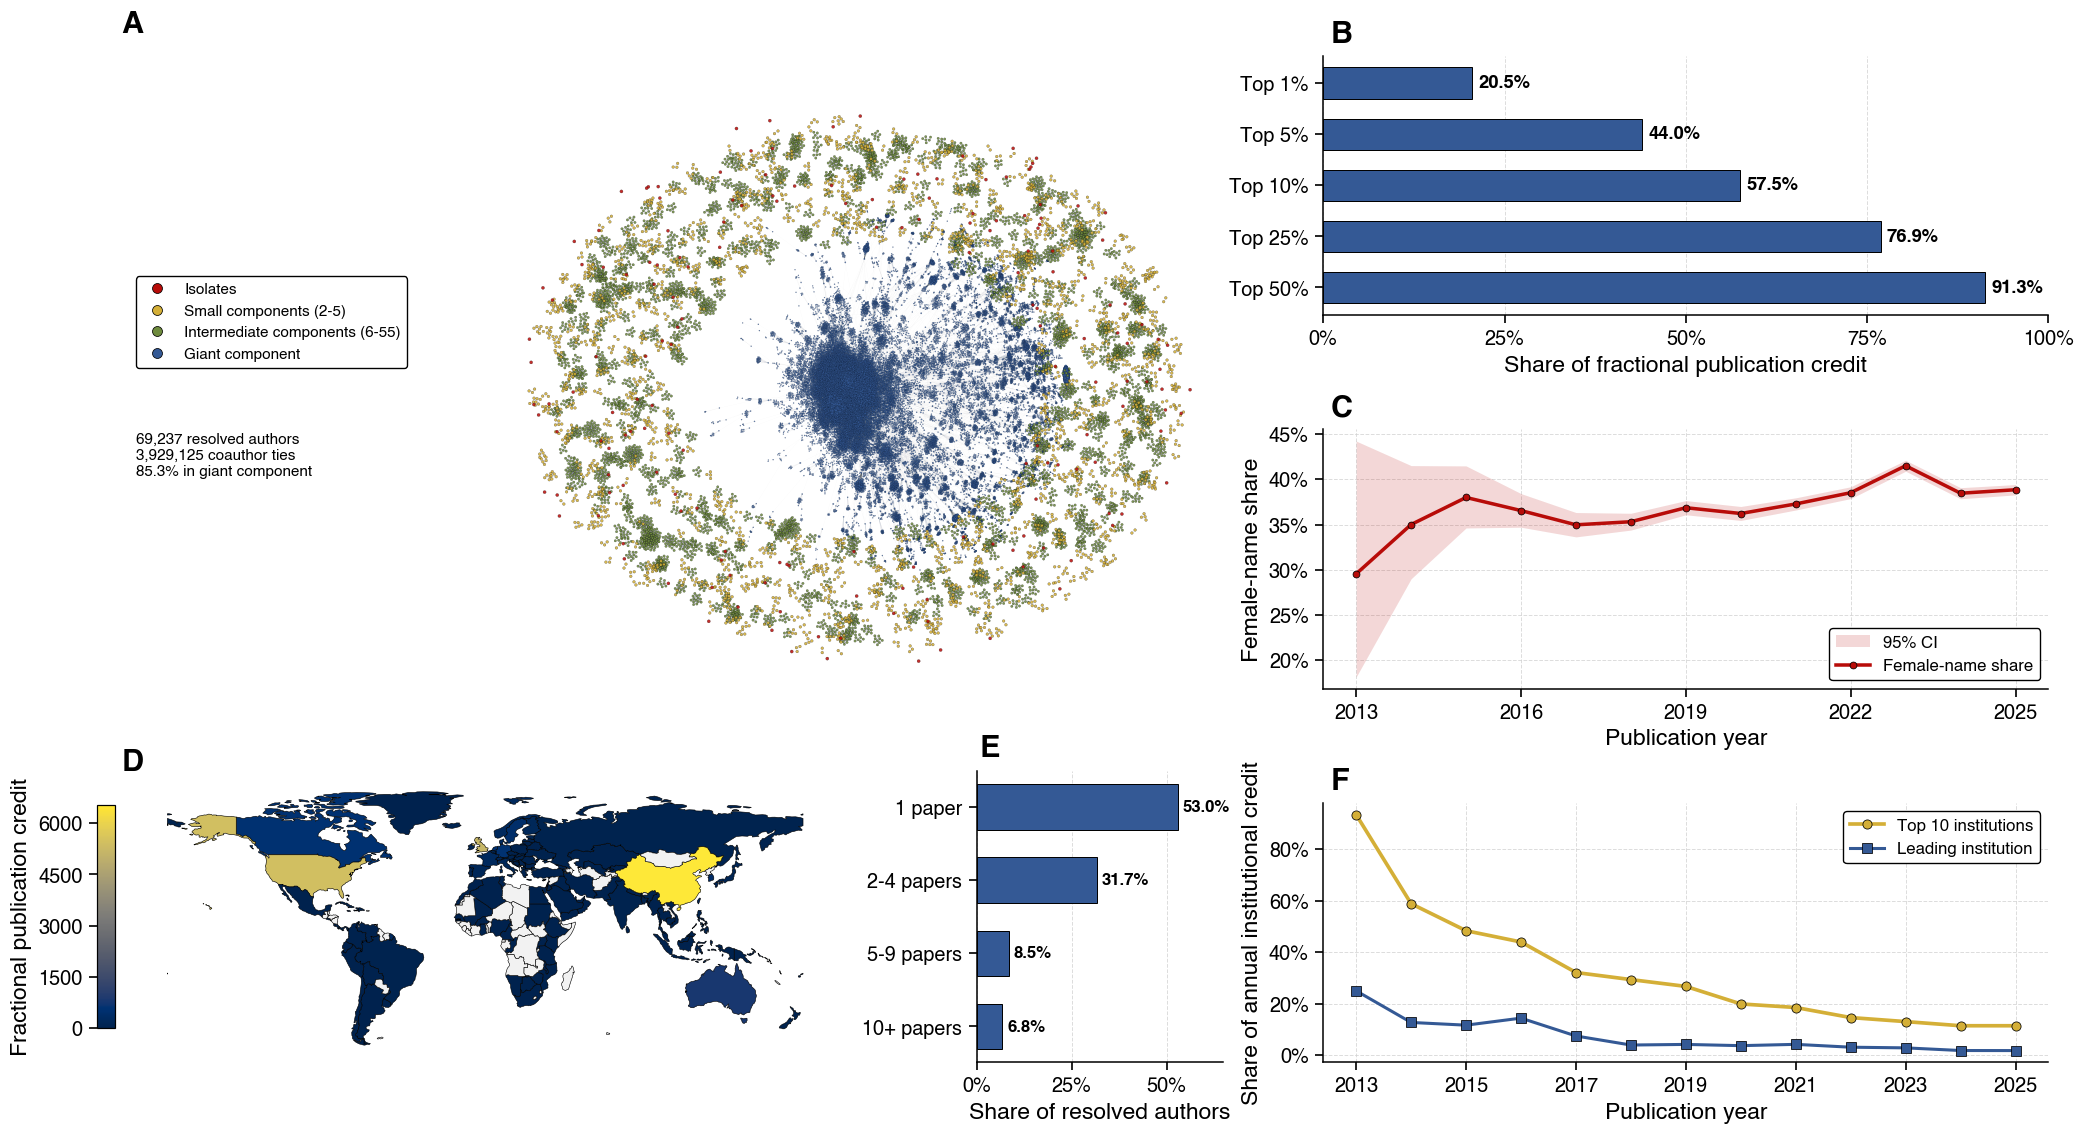

In [7]:
headline = A.headline_statistics(core, network)
display(headline)
fig, paths = F.plot_headline_figure(core, network, STYLE)
ARTIFACTS.record_figures(paths)
plt.show()

## Supplementary Figure 1: author productivity and impact

This author-only supplement preserves the legacy bibliometric work and expands it with a full UKB h-index distribution, productivity survival curve, impact-productivity association, and ranked leading authors.

saved output/figures/data_analysis/05_author_characteristics/05_02_supplementary_figure_01_author_metrics.pdf


saved output/figures/data_analysis/05_author_characteristics/05_02_supplementary_figure_01_author_metrics.svg


saved output/figures/data_analysis/05_author_characteristics/05_02_supplementary_figure_01_author_metrics.png


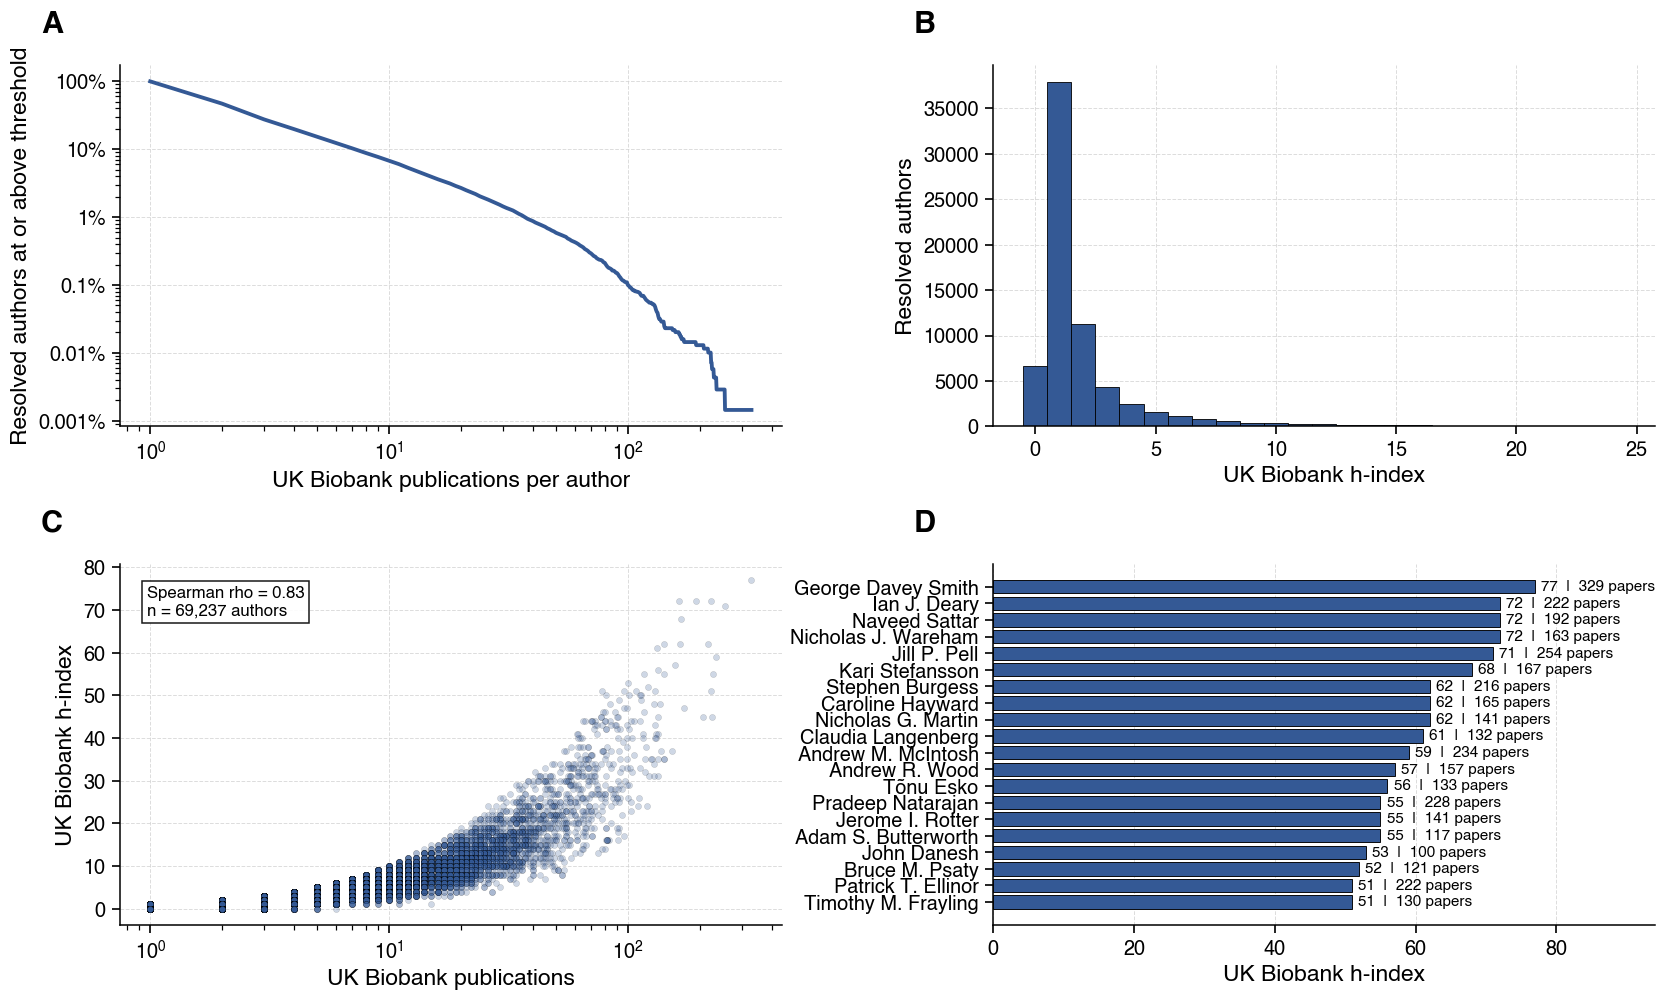

In [8]:
fig, paths = F.plot_author_metrics_supplement(core, STYLE)
ARTIFACTS.record_figures(paths)
plt.show()

## Supplementary Figure 2: name-inferred gender

This gender-only supplement emphasizes denominator transparency: composition counts, strict and expanded classification coverage, authorship position, and FOR division. Country and institution intersections are retained in exported tables rather than overloading the figure.

saved output/figures/data_analysis/05_author_characteristics/05_03_supplementary_figure_02_name_inferred_gender.pdf
saved output/figures/data_analysis/05_author_characteristics/05_03_supplementary_figure_02_name_inferred_gender.svg


saved output/figures/data_analysis/05_author_characteristics/05_03_supplementary_figure_02_name_inferred_gender.png


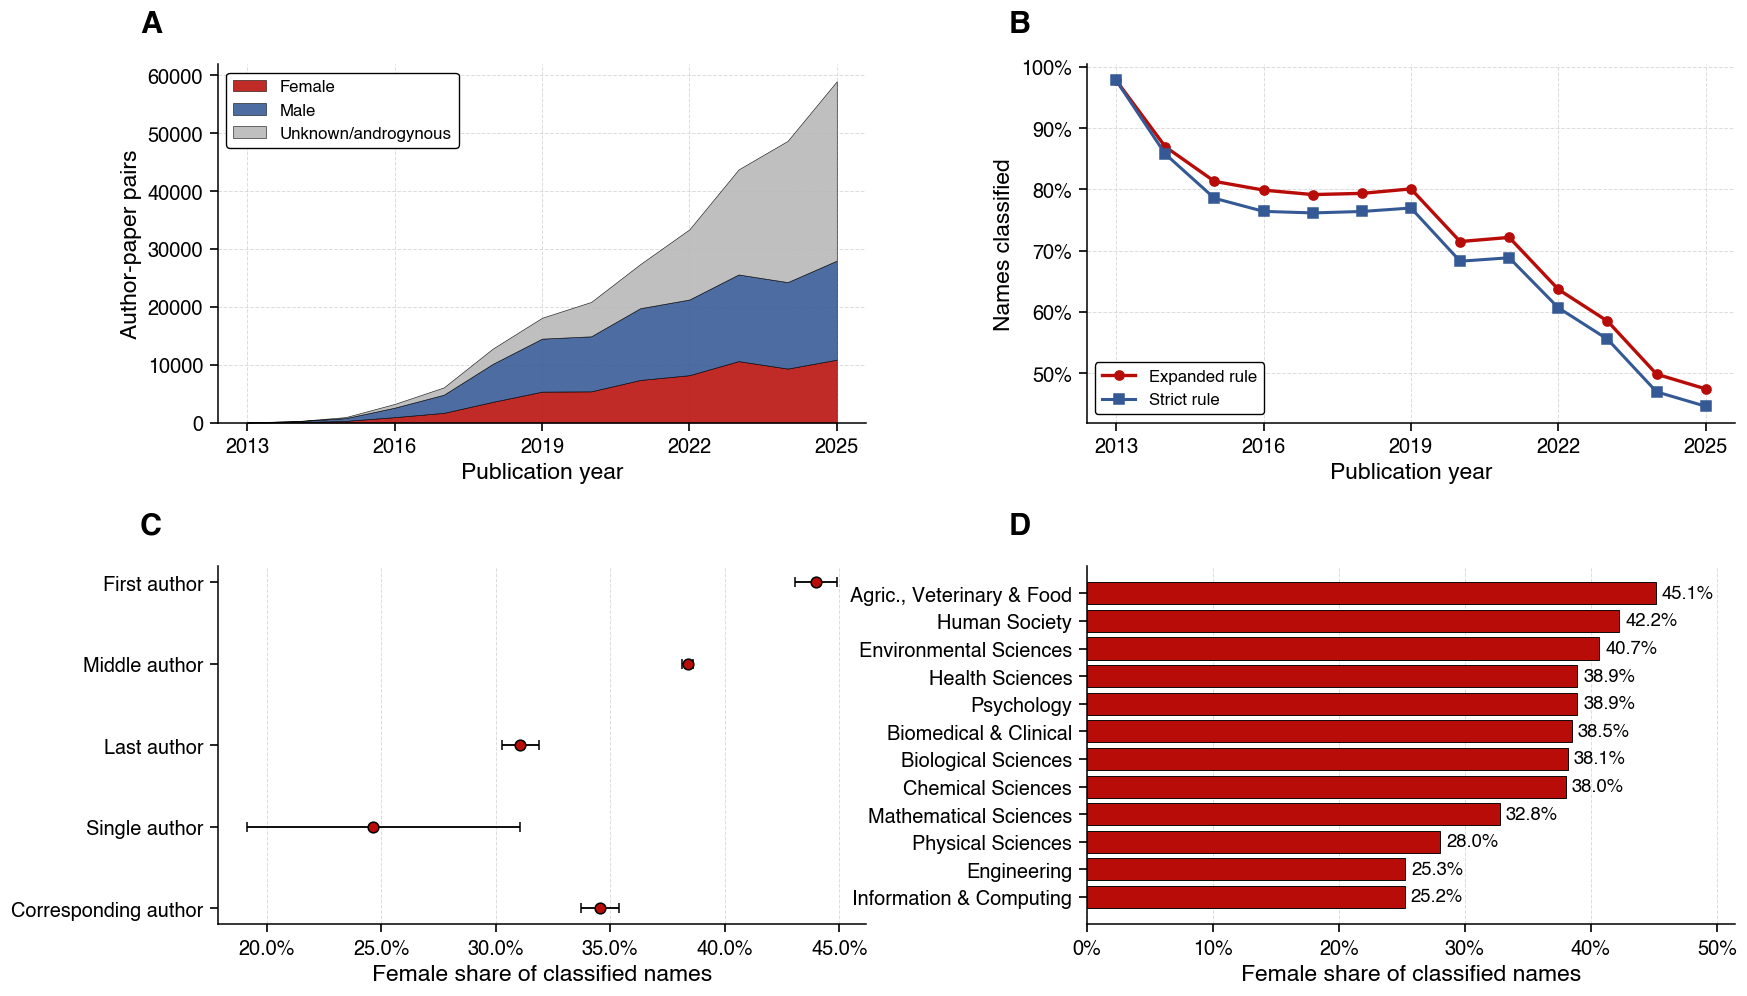

In [9]:
fig, paths = F.plot_gender_supplement(core, STYLE)
ARTIFACTS.record_figures(paths)
plt.show()

## Supplementary Figure 3: geography

This geography-only supplement complements the headline map with leading-country shares, author-affiliation and research-organization paper maps, author-paper intensity, annual country-coverage bars, and period-averaged lollipops for entropy-based geographic diversity. Period aggregation reduces sensitivity to annual endpoint lag. Maps use a fixed source geometry and logarithmic scales so both the global tail and leading countries remain visible.

saved output/figures/data_analysis/05_author_characteristics/05_04_supplementary_figure_03_geography.pdf


saved output/figures/data_analysis/05_author_characteristics/05_04_supplementary_figure_03_geography.svg


saved output/figures/data_analysis/05_author_characteristics/05_04_supplementary_figure_03_geography.png


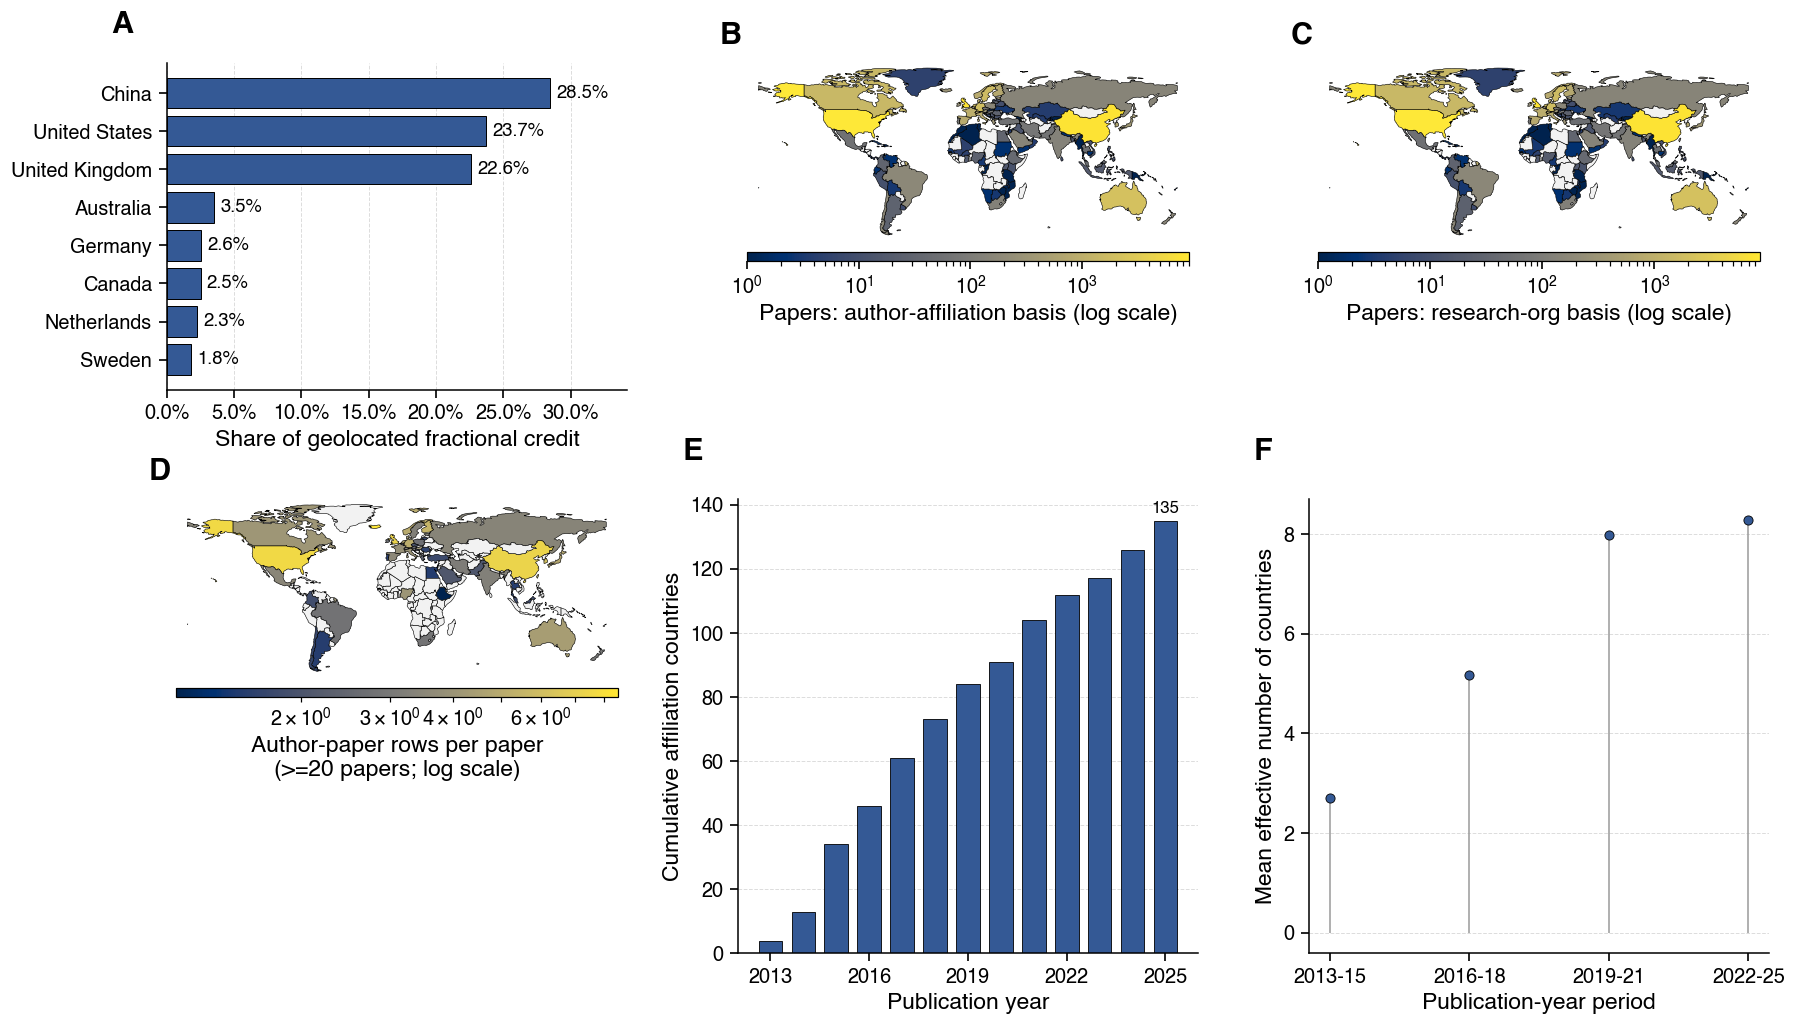

In [10]:
world = F.load_world_geometries()
fig, paths = F.plot_geography_supplement(core, STYLE, world=world)
ARTIFACTS.record_figures(paths)
plt.show()

## Supplementary Figure 4: institutions

This institution-only supplement retains fractional leading-institution bars partitioned over the complete multi-label FOR taxonomy, cumulative institutional uptake, and the association between institutional UKB impact and fractional publication credit.

saved output/figures/data_analysis/05_author_characteristics/05_05_supplementary_figure_04_institutions.pdf


saved output/figures/data_analysis/05_author_characteristics/05_05_supplementary_figure_04_institutions.svg


saved output/figures/data_analysis/05_author_characteristics/05_05_supplementary_figure_04_institutions.png


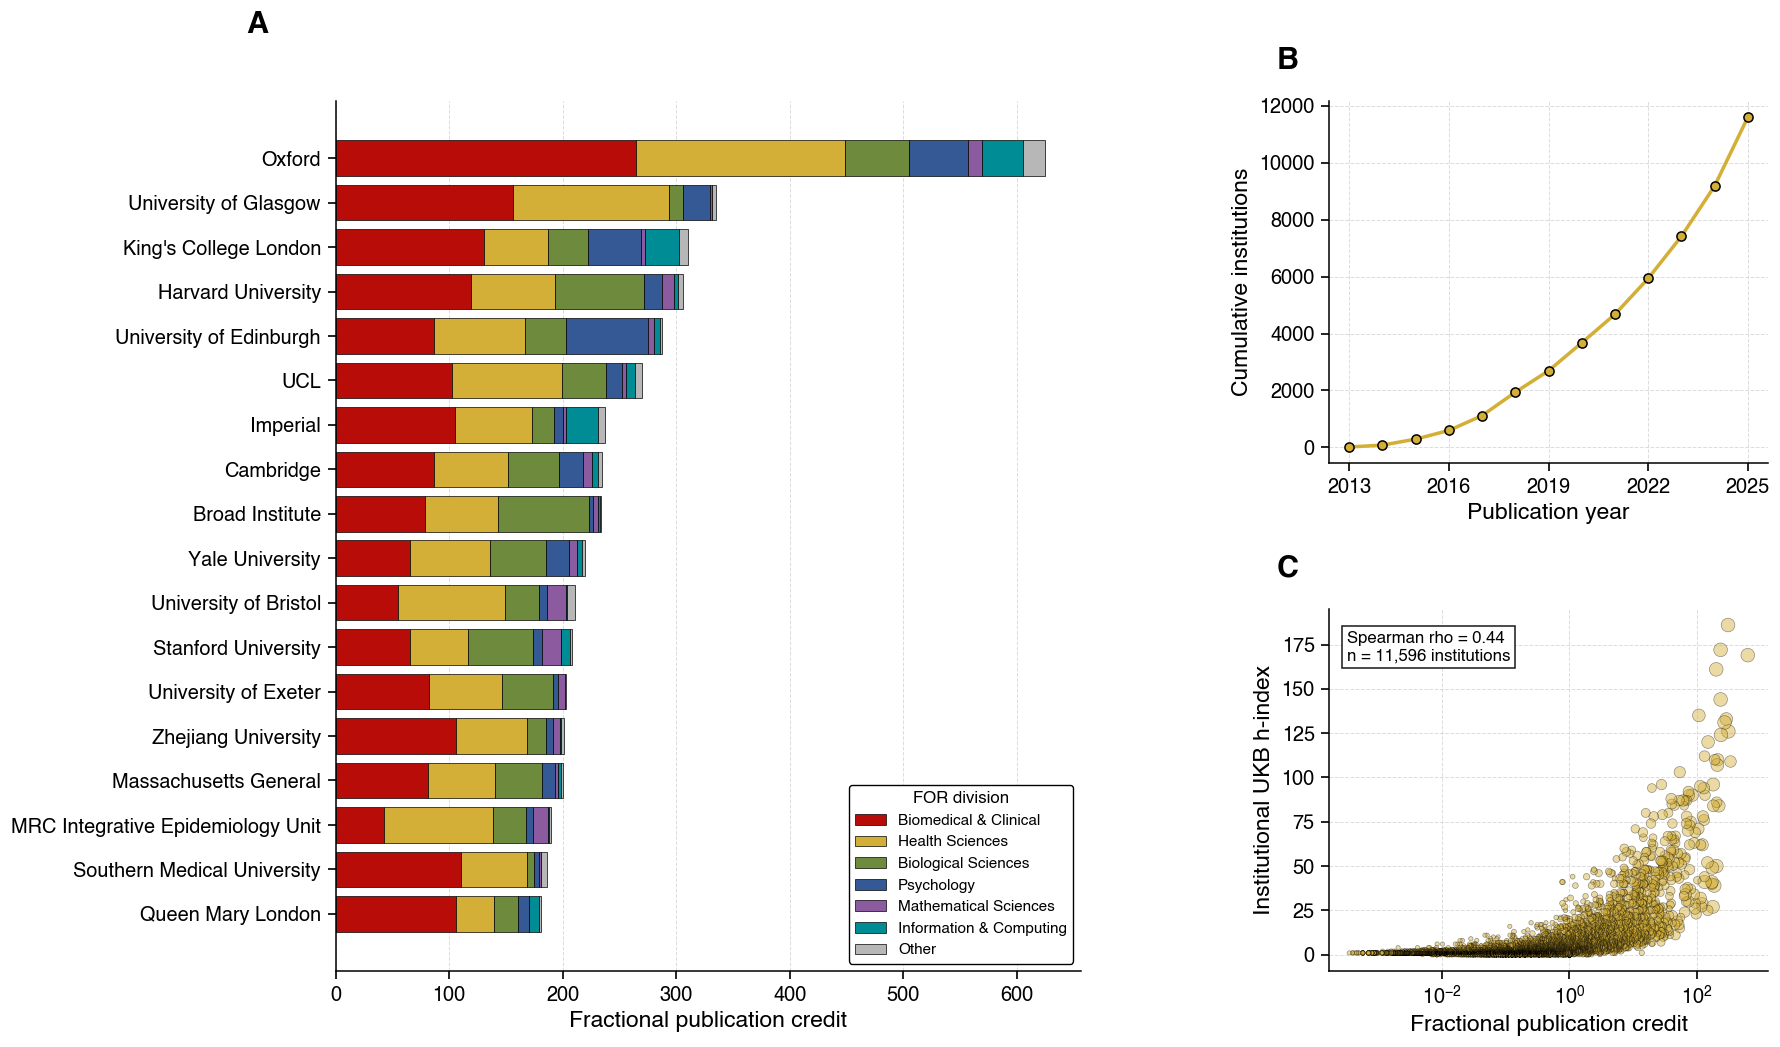

In [11]:
fig, paths = F.plot_institution_supplement(core, STYLE)
ARTIFACTS.record_figures(paths)
plt.show()

## Supplementary Figure 5: coauthorship structure

This network-only supplement avoids repeating the headline topology. It reports FOR composition within the 12 largest Leiden communities, annual entry of newly resolved authors, the publication-collaborator association, tie-strength composition, component rank-size structure, and an endpoint hyperauthorship sensitivity. Complete annual network trajectories remain in the exported table.

saved output/figures/data_analysis/05_author_characteristics/05_06_supplementary_figure_05_networks.pdf


saved output/figures/data_analysis/05_author_characteristics/05_06_supplementary_figure_05_networks.svg


saved output/figures/data_analysis/05_author_characteristics/05_06_supplementary_figure_05_networks.png


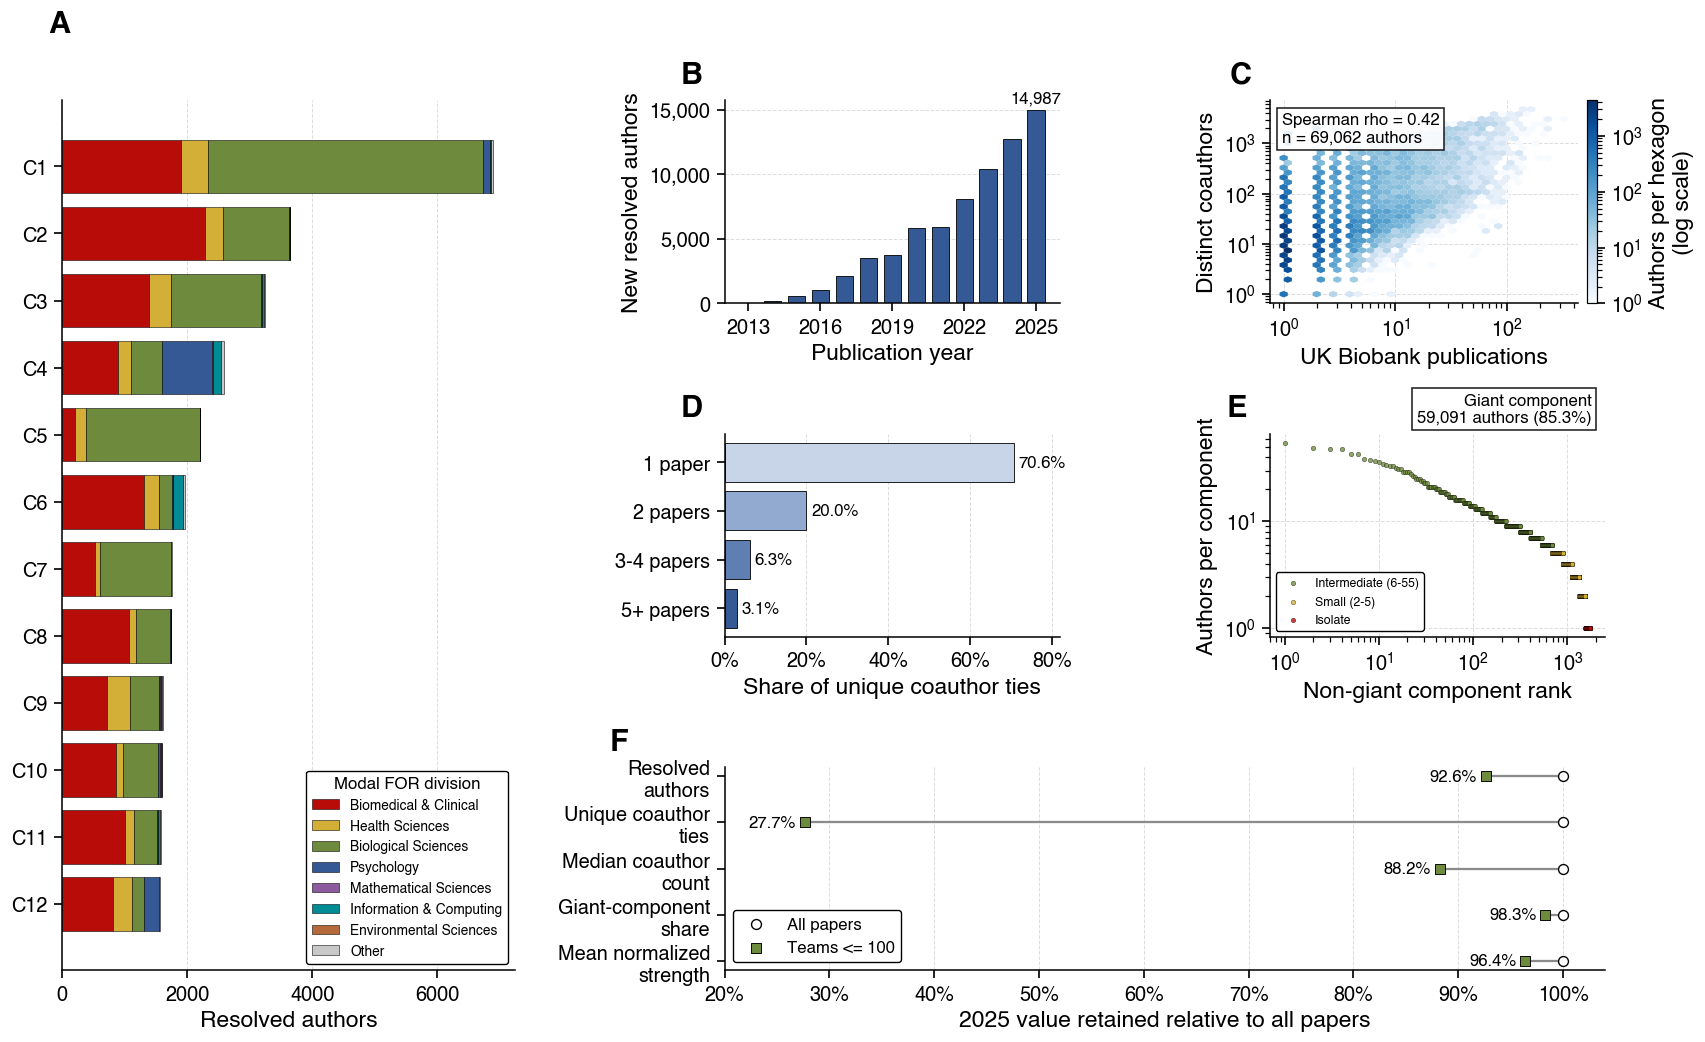

In [12]:
fig, paths = F.plot_network_supplement(core, network, STYLE)
ARTIFACTS.record_figures(paths)
plt.show()

## Tables, workbook, captions, methods, and manifest

The exported author table merges productivity, UKB-specific citation indices, name category, conserved modal field/geography/institution assignments, current and fallback home institutions, authorship position, and network characteristics. Full community-by-L2, L4, institution, country, and name-category count/share/rank tables are exported alongside the compact plotted labels. The legacy crosswalk records where every substantive former `05_*` figure and table now appears.

In [13]:
exports = A.export_analysis_artifacts(ARTIFACTS, source, papers, core, network)
manifest, manifest_path = ARTIFACTS.save_manifest("author_characteristics_manifest.csv")
display(exports["headline"])
display(exports["audit"])
display(exports["checks"])
display(manifest.groupby(["kind", "format"]).size().unstack(fill_value=0))
display(Markdown("**Analysis complete.** All displayed and exported paths are repository-relative."))

saved output/tables/data_analysis/05_author_characteristics/author_metrics.csv
saved output/tables/data_analysis/05_author_characteristics/author_credit_concentration.csv
saved output/tables/data_analysis/05_author_characteristics/author_productivity_bands.csv
saved output/tables/data_analysis/05_author_characteristics/paper_for_assignments.csv
saved output/tables/data_analysis/05_author_characteristics/institution_metrics.csv
saved output/tables/data_analysis/05_author_characteristics/country_metrics.csv
saved output/tables/data_analysis/05_author_characteristics/gender_by_year.csv
saved output/tables/data_analysis/05_author_characteristics/gender_by_authorship_role.csv
saved output/tables/data_analysis/05_author_characteristics/gender_by_for_division.csv
saved output/tables/data_analysis/05_author_characteristics/gender_by_country.csv
saved output/tables/data_analysis/05_author_characteristics/gender_by_institution.csv
saved output/tables/data_analysis/05_author_characteristics/count

saved output/tables/data_analysis/05_author_characteristics/network_author_metrics.csv
saved output/tables/data_analysis/05_author_characteristics/network_community_membership.csv
saved output/tables/data_analysis/05_author_characteristics/network_community_summary.csv
saved output/tables/data_analysis/05_author_characteristics/network_collapsed_nodes.csv
saved output/tables/data_analysis/05_author_characteristics/network_collapsed_edges.csv
saved output/tables/data_analysis/05_author_characteristics/headline_summary_statistics.csv
saved output/tables/data_analysis/05_author_characteristics/data_quality_audit.csv
saved output/tables/data_analysis/05_author_characteristics/analysis_validation_checks.csv
saved output/tables/data_analysis/05_author_characteristics/metric_definitions.csv
saved output/tables/data_analysis/05_author_characteristics/analysis_parameters.csv
saved output/tables/data_analysis/05_author_characteristics/legacy_artifact_crosswalk.csv
saved output/tables/data_analys

saved output/tables/data_analysis/05_author_characteristics/supplementary_author_characteristics.xlsx
saved output/tables/data_analysis/05_author_characteristics/figure_01_caption.txt
saved output/tables/data_analysis/05_author_characteristics/supplementary_figure_01_caption.txt
saved output/tables/data_analysis/05_author_characteristics/supplementary_figure_02_caption.txt
saved output/tables/data_analysis/05_author_characteristics/supplementary_figure_03_caption.txt
saved output/tables/data_analysis/05_author_characteristics/supplementary_figure_04_caption.txt
saved output/tables/data_analysis/05_author_characteristics/supplementary_figure_05_caption.txt
saved output/tables/data_analysis/05_author_characteristics/methods_author_characteristics.txt
saved output/tables/data_analysis/05_author_characteristics/author_characteristics_manifest.csv


,statistic,value,unit_or_definition
0,Resolved authors,69237.000000,authors
1,Author-paper pairs,274603.000000,authorships
2,Authors with one UKB paper,53.035227,% resolved authors
3,Author credit Gini,0.685374,0=equality; 1=concentration
4,Credit held by top 1% of authors,20.490964,% resolved-author fractional publication credit
5,Credit held by top 5% of authors,43.976837,% resolved-author fractional publication credit
6,Credit held by top 10% of authors,57.462446,% resolved-author fractional publication credit
7,Credit held by top 25% of authors,76.880887,% resolved-author fractional publication credit
8,Credit held by top 50% of authors,91.253194,% resolved-author fractional publication credit
9,"Female-name share, 2013",29.545455,% classified authorships


,metric,value,interpretation
0,Source parquet records,26109.00,includes provisional years
1,Records after 2025,2667.00,excluded from primary analysis
2,Complete-year papers,23442.00,2013-2025
3,Papers with parsed authors,23407.00,author-based denominator
4,Papers without parsed authors,35.00,retained in source audit only
5,Parsed author-paper pairs,274603.00,deduplicated within paper
6,Resolved author-paper pairs,242663.00,Dimensions researcher ID present
7,Unresolved author-paper pairs,31940.00,paper-local IDs; never merged by name
8,Unique resolved authors,69237.00,author table rows
9,Author homes from current organization,62116.00,GRID-resolved current organization


,check,passed,observed,expected
0,unique_source_publication_ids,True,26109,26109
1,complete_year_window,True,2013-2025,2013-2025
2,unique_author_paper_pairs,True,274603,274603
3,authorship_credit_sums_to_one,True,0.0,<=1e-9
4,country_credit_never_exceeds_one,True,1.0,<=1
5,institution_credit_never_exceeds_one,True,1.0,<=1
6,institution_credit_conserved,True,0.0,<=1e-9
7,country_credit_conserved,True,0.0,<=1e-9
8,fractional_credits_nonnegative,True,nonnegative,nonnegative
9,ukb_h_index_bounded_by_papers,True,77,<= n_ukb_papers


format,csv,pdf,png,svg,txt,xlsx
kind,,,,,,
figure,0,6,6,6,0,0
table_or_text,46,0,0,0,7,1


**Analysis complete.** All displayed and exported paths are repository-relative.